In [1]:
import os
import pandas as pd 
import numpy as np 

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.ortho_proj_hatz import *

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns 

%matplotlib inline

In [2]:
os.chdir('../data')
true_data = np.load('geyser.npy').astype(np.float64)
waiting = true_data[:, 0].reshape(-1, 1)

bw = 4.9

xlimit = (1., 210.)
den_plot_xlim = (25., 125.) 

kernel_function = GaussianPoly2(waiting, 1.0, 0., 0., bw)
base_density = BasedenGamma(waiting, a = 36., scale = 2.)

In [3]:
pd.Series(waiting.flatten()).describe()

count    299.000000
mean      72.314381
std       13.890324
min       43.000000
25%       59.000000
50%       76.000000
75%       83.000000
max      108.000000
dtype: float64

In [4]:
new_data = np.linspace(xlimit[0], xlimit[1], 3000).reshape(-1, 1)
y_C = hatz_projection_C(
    data = waiting, 
    new_data = new_data, 
    kernel_function = kernel_function, 
    base_density = base_density)

y_perp = hatz_projection_C_perp(
    data = waiting, 
    new_data = new_data, 
    kernel_function = kernel_function, 
    base_density = base_density)

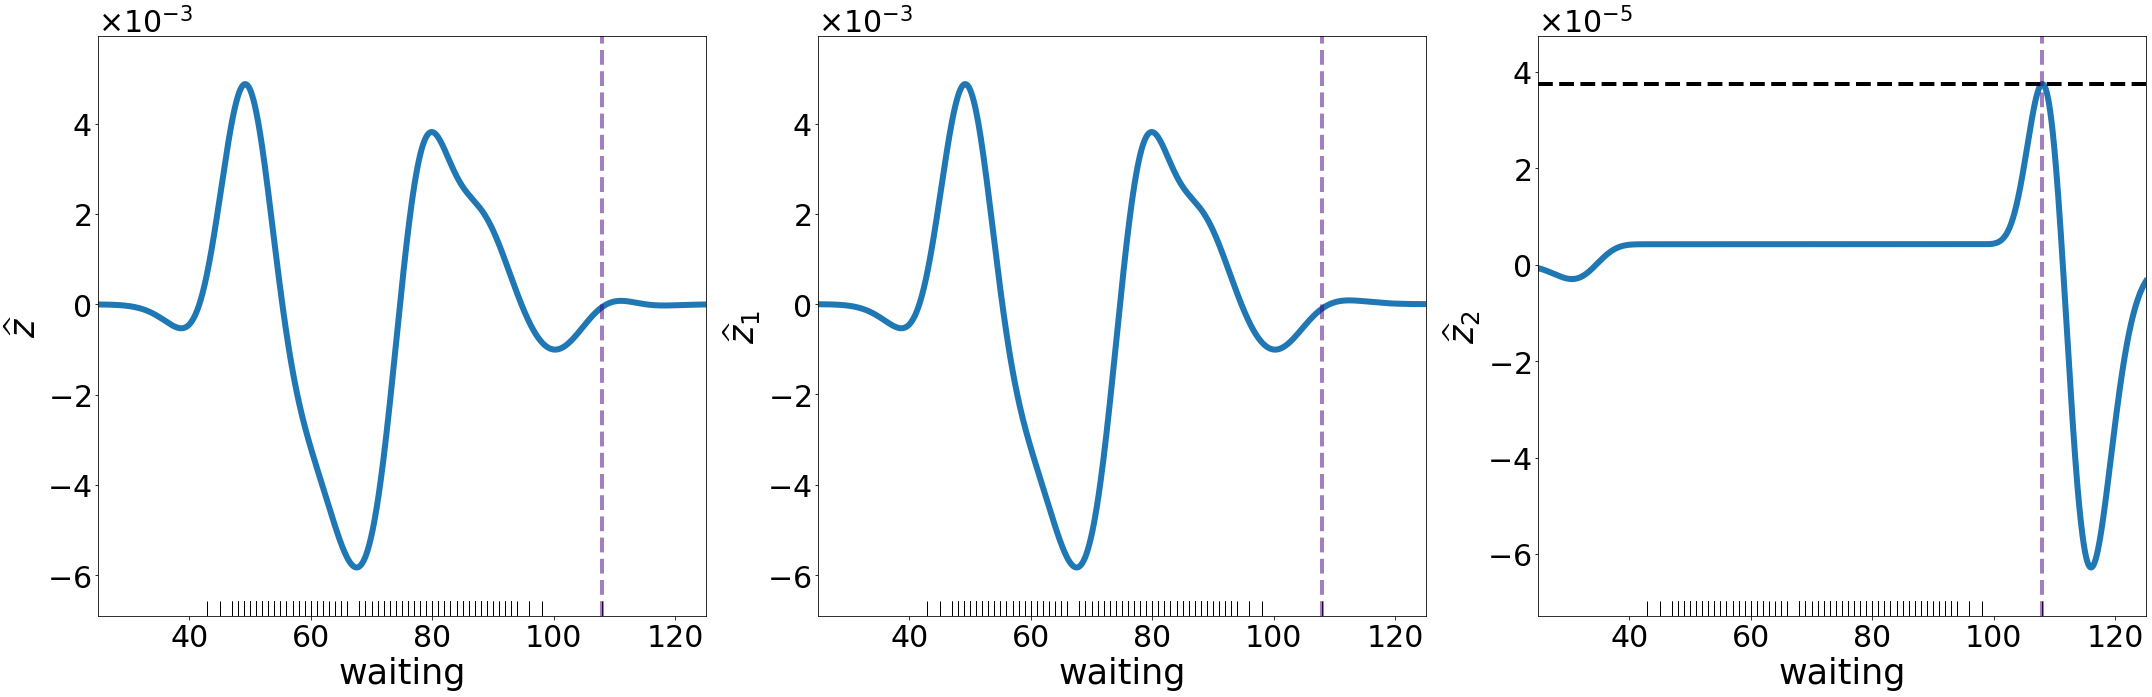

In [7]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
linewidth1 = 4.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 6
color = 'tab:blue'
vline_color = 'indigo'

fig = plt.figure(figsize=(60, 18))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

# ----------------------------------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

ax.plot(new_data.flatten(), (y_C + y_perp).flatten(), linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')

ax.set_xlim(den_plot_xlim)
# ax.set_ylim(den_plot_ylim)
ax.set_xlabel(x_label, fontsize = label_fontsize)
ax.set_ylabel(r'$\widehat{z}$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)
ax.axvline(x = 108., ymin = 0, ymax = 1, linewidth = linewidth1, 
           linestyle = 'dashed', color = vline_color, alpha = 0.5)

ax.ticklabel_format(axis = 'y', style = 'scientific', scilimits = (0, 0), useMathText = True)
ax.yaxis.offsetText.set_fontsize(tick_fontsize)

# plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
# ax.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                      color = 'indigo', fill = False, linewidth = 7.0)))

# if i == 0: 
#     ax.set_ylabel(y_label, fontsize = label_fontsize)
# else: 
#     ax.set_yticks([])

# info = r"$\widehat{z}$"
# ax.text(*info_coord,
#         info,
#         fontsize = info_fontsize,
#         multialignment = 'left',
#         horizontalalignment = horizontalalignment, 
#         verticalalignment = verticalalignment, 
#         transform = ax.transAxes,
#         bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

ax.plot(new_data.flatten(), y_C.flatten(), linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')

ax.set_xlim(den_plot_xlim)
# ax.set_ylim(den_plot_ylim)
ax.set_xlabel(x_label, fontsize = label_fontsize)
ax.set_ylabel(r'$\widehat{z}_1$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)
ax.axvline(x = 108., ymin = 0, ymax = 1, linewidth = linewidth1, 
           linestyle = 'dashed', color = vline_color, alpha = 0.5)

ax.ticklabel_format(axis = 'y', style = 'scientific', scilimits = (0, 0), useMathText = True)
ax.yaxis.offsetText.set_fontsize(tick_fontsize)

# plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
# ax.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                      color = 'indigo', fill = False, linewidth = 7.0)))

# if i == 0: 
#     ax.set_ylabel(y_label, fontsize = label_fontsize)
# else: 
#     ax.set_yticks([])

# info = r"$\widehat{z}_1$"
# ax.text(*info_coord,
#         info,
#         fontsize = info_fontsize,
#         multialignment = 'left',
#         horizontalalignment = horizontalalignment, 
#         verticalalignment = verticalalignment, 
#         transform = ax.transAxes,
#         bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 2])

ax.plot(new_data.flatten(), y_perp.flatten(), linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')

ax.set_xlim(den_plot_xlim)
# ax.set_ylim(den_plot_ylim)
ax.set_xlabel(x_label, fontsize = label_fontsize)
ax.set_ylabel(r'$\widehat{z}_2$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)
ax.axvline(x = 108., ymin = 0, ymax = 1, linewidth = linewidth1, 
           linestyle = 'dashed', color = vline_color, alpha = 0.5)
ax.axhline(y = np.max(y_perp.flatten()), xmin = 0, xmax = 1, 
           linewidth = linewidth1, linestyle = 'dashed', color = 'k')

ax.ticklabel_format(axis = 'y', style = 'scientific', scilimits = (0, 0), useMathText = True)
ax.yaxis.offsetText.set_fontsize(tick_fontsize)

# plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
# ax.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                      color = 'indigo', fill = False, linewidth = 7.0)))

# if i == 0: 
#     ax.set_ylabel(y_label, fontsize = label_fontsize)
# else: 
#     ax.set_yticks([])

# info = r"$\widehat{z}_2$"
# ax.text(*info_coord,
#         info,
#         fontsize = info_fontsize,
#         multialignment = 'left',
#         horizontalalignment = horizontalalignment, 
#         verticalalignment = verticalalignment, 
#         transform = ax.transAxes,
#         bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/chapter-3-decomposition-hat-z-bw={bw}-Gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')
plt.show()